In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install python_speech_features

  Preparing metadata (setup.py) ... done
  Created wheel for python_speech_features: filename=python_speech_features-0.6-py3-none-any.whl size=5870 sha256=0e4c5a2b3661ca39984f22c4ca7e951706b8a431bca1266f32e4eace5af5a672
  Stored in directory: /root/.cache/pip/wheels/5a/9e/68/30bad9462b3926c29e315df16b562216d12bdc215f4d240294
Successfully built python_speech_features


In [3]:
import os
from scipy.io import wavfile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from keras.layers import Conv2D, MaxPool2D, Flatten, LSTM
from keras.layers import Dropout, Dense, TimeDistributed
from keras.models import Sequential
from keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
from python_speech_features import mfcc
import random
#from tensorflow.keras import regularizers

In [4]:
dir_path ='/content/drive/MyDrive/final_project/second_draft'
data_clean = "clean"

In [5]:
# normalize to range [0; 1]
def normalize(x):
    x_normalized = (x - np.amin(x)) / (np.amax(x) - np.amin(x))
    return x_normalized

def standardize(x):
    x_standardized = (x - np.mean(x)) / np.std(x)
    return x_standardized


# This function creates the matrices to train on by randomly sampling the audio files at different intervals.
# We are creating in X and y. X is individual recordings and y is correponding instrument
# We need to built aribituary length for each recording
def generate_feature_samples(df, n_samples):

  # initialize results data structures
  X = []
  y = []

  # initialize variables for the smallest and the largest values in the 'spectrogram'
  _min, _max = float("inf"), -float("inf")

  for _ in tqdm(range(n_samples)):
    # draw a random label
    rand_class = np.random.choice(class_dist.index, p=prob_dist)

    # draw a random file that contains data for that label
    file = np.random.choice(df[df.label==rand_class].index)

    # read the file
    rate, wav = wavfile.read(dir_path + "/"+ data_clean + "/" + file)

    # WTF? we already have the label?
    label = df.at[file, "label"]

    # draw a random number which will serve as the beginning of the interval to sample (has to be in [0; total length - extraction window])
    sample_index = np.random.randint(0, wav.shape[0]-config.sample_length)

    # extract a sample corresponding to a length of config.sample_length, starting at sample_index
    sample = wav[sample_index:sample_index+config.sample_length]

    # compute the 'spectrogram' on the extracted sample
    sample_mfcc = mfcc(sample, rate, numcep=config.nfeat, nfilt=config.nfilt, nfft=config.nfft).T

    # normalize every spectogram to range [0; 1]
    normalized_sample_mfcc = normalize(sample_mfcc)

    # normalize every spectogram to range [0; 1]
    standardized_sample_mfcc = standardize(sample_mfcc)
    # We can choose which one we want to use but I will go with normalized sample
    #sample_complete = np.concatenate( (sample_mfcc, normalized_sample_mfcc, standardized_sample_mfcc) )
    sample_used = normalized_sample_mfcc
    # append sample spectrogram
    X.append(sample_used if config.mode == "conv" else sample_used.T)

    # append sample label
    y.append(classes.index(label))

  # convert lists of spectrograms and labels to arrays of arrays
  X, y = np.array(X), np.array(y)

  if config.mode == "conv":
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
  elif config.mode == "time":
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2])

  y_categorical = to_categorical(y, num_classes=config.n_classes)
  return X, y_categorical #y,

In [6]:
def get_conv_model(n_classes, input_shape):
  model = Sequential()
  model.add(Conv2D(16, (3, 3), activation = "relu", strides = (1, 1),
                   padding = "same", input_shape = input_shape))
  model.add(Conv2D(32, (3, 3), activation = "relu", strides = (1, 1),
                   padding = "same"))
  model.add(Conv2D(64, (3, 3), activation = "relu", strides = (1, 1),
                   padding = "same"))
  model.add(Conv2D(128, (3, 3), activation = "relu", strides = (1, 1),
                   padding = "same"))
  model.add(MaxPool2D((2, 2)))
  model.add(Dropout(0.5))
  model.add(Flatten())
  model.add(Dense(128, activation="relu"))
  model.add(Dense(64, activation="relu"))
  model.add(Dense(n_classes, activation="softmax"))
  model.summary()
  model.compile(loss="categorical_crossentropy",
                optimizer="adam",
                metrics=["acc"])
  return model

In [7]:
def get_recurrent_model(n_classes):
  # shape of data for RNN is (n, time, feat)
  model = Sequential()
  model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
  model.add(LSTM(128, return_sequences=True))
  model.add(Dropout(0.5))
  model.add(TimeDistributed(Dense(64, activation="relu")))
  model.add(TimeDistributed(Dense(32, activation="relu")))
  model.add(TimeDistributed(Dense(16, activation="relu")))
  model.add(TimeDistributed(Dense(8, activation="relu")))
  model.add(Flatten())
  model.add(Dense(n_classes, activation="softmax"))
  model.summary()
  model.compile(loss="categorical_crossentropy",
                optimizer="adam",
                metrics=["acc"])
  return model

In [8]:
class Config:
  def __init__(self, mode="conv", nfilt=26, nfeat=13, nfft=512, rate=16000, sample_length = None, n_classes=2, n_train_samples=3000, n_val_samples=300):
    self.mode = mode
    self.nfilt = nfilt
    self.nfeat = nfeat
    self.nfft = nfft
    self.rate = rate
    self.sample_length = int(sample_length) if rate is not None else int(rate/10) # sample length in samples not seconds
    self.n_classes = n_classes
    self.n_train_samples = n_train_samples
    self.n_val_samples = n_val_samples

In [9]:
df_1 = pd.read_csv(dir_path + '/train_info.csv')
df_2 = pd.read_csv(dir_path + '/test_info.csv')
df = pd.concat([df_1, df_2])

In [10]:
df.set_index('fname', inplace=True)
df.head()

,Unnamed: 0,label,length,participant
fname,,,,
1.0_vfy_p_2_list_1_35.wav,0,vfy,1.690930,p_2
1.6_vfy_p_4_list_4_33.wav,1,vfy,1.525986,p_4
0.4_vfy_p_4_list_4_27.wav,2,vfy,1.203401,p_4
1.0_vfy_p_2_list_1_8.wav,3,vfy,2.258322,p_2
1.6_vfy_p_6_list_3_2.wav,4,vfy,1.448707,p_6


In [11]:
for f in df.index:
    rate, signal = wavfile.read(dir_path + "/clean/"+f)
    df.at[f, 'length_samples'] = signal.shape[0]
    df.at[f, 'length_sec'] = signal.shape[0]/rate
    df.at[f, 'avg_amplitude'] = np.abs(signal).mean()

In [12]:
df.loc[df["length_sec"]<0.9]

,Unnamed: 0,label,length,participant,length_samples,length_sec,avg_amplitude
fname,,,,,,,
0.6_vfy_p_1_list_1_21.wav,184,vfy,0.816780,p_1,13069.0,0.816813,0.009508
0.8_n_p_7_list_5_35.wav,1047,normal,0.897823,p_7,13323.0,0.832688,0.004840
0.6_n_p_7_list_4_23.wav,1559,normal,1.062404,p_7,12470.0,0.779375,0.005732
1.6_n_p_7_list_4_24.wav,1726,normal,0.901406,p_7,12173.0,0.760813,0.006164


In [13]:
classes = list(np.unique(df.label))
class_dist = df.groupby(['label'])['length_sec'].mean()

In [14]:
from numpy.random.mtrand import choice
# we will move randomly sample along the len of files and take a 1 sec chunk of audio
# we will move every 10 sec
n_samples = 2 * int(df["length_sec"].sum()/0.1) #what is the total length in sec 10th of a sec
prob_dist = class_dist/class_dist.sum()
choices = np.random.choice(class_dist.index, p=prob_dist)

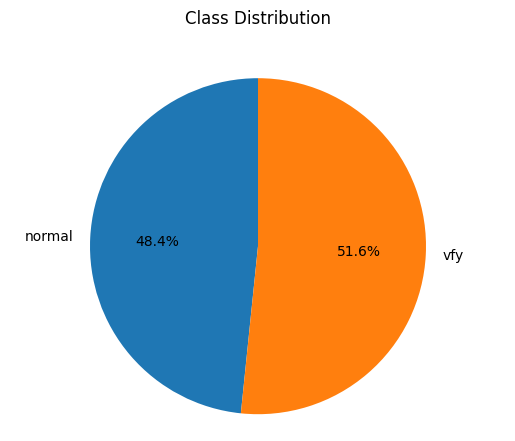

In [ ]:
fig, ax = plt.subplots()
ax.set_title('Class Distribution', y=1.08)
ax.pie(class_dist, labels=class_dist.index, autopct='%1.1f%%',
       shadow=False, startangle=90)
ax.axis('equal')
plt.show()

# Cross Validation Starts

In [15]:
# We don't exclude anything yet but we will use this code later for the full traning data.
values_to_exclude = [] #['p_6', 'p_9']
df_train = df[~df['participant'].isin(values_to_exclude)]
df_train.head()

,Unnamed: 0,label,length,participant,length_samples,length_sec,avg_amplitude
fname,,,,,,,
1.0_vfy_p_2_list_1_35.wav,0,vfy,1.690930,p_2,24348.0,1.521750,0.005667
1.6_vfy_p_4_list_4_33.wav,1,vfy,1.525986,p_4,22733.0,1.420813,0.010805
0.4_vfy_p_4_list_4_27.wav,2,vfy,1.203401,p_4,18643.0,1.165188,0.009486
1.0_vfy_p_2_list_1_8.wav,3,vfy,2.258322,p_2,33722.0,2.107625,0.008322
1.6_vfy_p_6_list_3_2.wav,4,vfy,1.448707,p_6,22695.0,1.418438,0.011502


<ipython-input-35-9ebfcfac0872>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df_train, x='length_samples', y='label', inner='box', palette='Dark2')


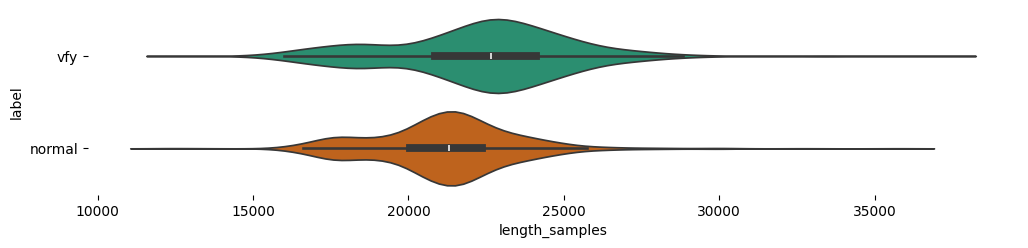

In [35]:
# @title label vs length_samples

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df_train['label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_train, x='length_samples', y='label', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [16]:
from sklearn.model_selection import StratifiedKFold
from tensorflow import keras
#from tensorflow.keras import layers

In [17]:
participants = df_train['participant'].unique()
participants

array(['p_2', 'p_4', 'p_6', 'p_3', 'p_5', 'p_1', 'p_7', 'p_10', 'p_12',
       'p_8', 'p_11', 'p_9'], dtype=object)

In [18]:
# Manually specify participants for each fold.  Females were paired with females, and males were paired with males.
folds = np.array([
    ['p_1', 'p_10'],
    ['p_2', 'p_11'],
    ['p_3', 'p_12'],
    ['p_4', 'p_7'],
    ['p_5', 'p_8'],
    ['p_6', 'p_9']
])
folds

array([['p_1', 'p_10'],
       ['p_2', 'p_11'],
       ['p_3', 'p_12'],
       ['p_4', 'p_7'],
       ['p_5', 'p_8'],
       ['p_6', 'p_9']], dtype='<U4')

In [ ]:
#### MODEL FITTING #####

In [19]:
df.length_samples.min()

12173.0

In [20]:
df["participant"].value_counts()


p_11    227
p_9     225
p_12    224
p_8     219
p_7     218
p_10    217
p_5     185
p_1     180
p_2     175
p_4     173
p_3     152
p_6     147
Name: participant, dtype: int64

In [21]:
# maximum sample length: df.length_samples.min()-1

sampling_rate = 16000
sample_duration_sec = 0.3
sample_length = sample_duration_sec*sampling_rate

config = Config(mode = "conv", n_classes = 2, sample_length = sample_length-1, n_train_samples=2000, n_val_samples=400)

In [22]:
def init_model(config, df_train, df_validation):
  if config.mode == "conv":
    X_train, y_train = generate_feature_samples(df_train, config.n_train_samples)
    X_validation, y_validation = generate_feature_samples(df_validation, config.n_val_samples)
    y_flat = np.argmax(y_train, axis =1)
    input_shape = (X_train.shape[1], X_train.shape[2], 1)
    model = get_conv_model(config.n_classes, input_shape)

  elif config.mode == "time":
    #X_train, y_train = generate_feature_samples(df_train, config.n_train_samples)
    #X_test, y_test = generate_feature_samples(df_test, config.n_test_samples)
    #y_flat = np.argmax(y_train, axis =1)
    #input_shape = (X_train.shape[1], X_train.shape[2])
    #model = get_recurrent_model(config.n_classes)
    pass

  return model, (X_train, y_train), (X_validation, y_validation)


In [23]:

#X_validation, y_validation = Xy_validation
#val_loss, val_accuracy = model.evaluate(X_validation, y_validation, verbose=0)
#predictions = model.predict(X_validation) # Use for the app


def evaluate_fold(config, df_train, df_validation):
  # Initiliazes a model, creates train and validation samples
  model, Xy_train, Xy_validation = init_model(config = config, df_train = cur_df_train, df_validation = cur_df_validation)

  # Fits the model in given parameters
  X_train, y_train = Xy_train
  res = model.fit(X_train, y_train, validation_data=Xy_validation,
            epochs=5, batch_size=32,
            shuffle=True,
            class_weight=None,
            verbose="auto")
  # Returns the accuracy and the loss of validation fold
  final_acc, final_loss = res.history['val_acc'][-1], res.history['val_loss'][-1]
  return final_acc, final_loss


In [24]:
validation_accuracy = []
validation_loss = []

for i in range(len(folds)):
    print(f"\n\n\n *** Running Fold {i+1}/{len(folds)} ***\n\n\n")

    validation_participants = folds[i]

    # Get the validation data for this fold.
    cur_df_validation = df_train[df_train['participant'].isin(validation_participants)]

    # Get the training data for this fold.
    cur_df_train = df_train[~df_train['participant'].isin(validation_participants)]

    accuracy, loss = evaluate_fold(config, cur_df_train, cur_df_validation)

    validation_accuracy.append(accuracy)
    validation_loss.append(loss)






 *** Running Fold 1/6 ***





100%|██████████| 400/400 [00:02<00:00, 166.11it/s]


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 13, 29, 16)        160       
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 29, 32)        4640      
                                                                 
 conv2d_2 (Conv2D)           (None, 13, 29, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 13, 29, 128)       73856     
                                                                 
 max_pooling2d (MaxPooling2  (None, 6, 14, 128)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 6, 14, 128)        0         
                                                        

100%|██████████| 400/400 [00:02<00:00, 161.29it/s]


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 13, 29, 16)        160       
                                                                 
 conv2d_5 (Conv2D)           (None, 13, 29, 32)        4640      
                                                                 
 conv2d_6 (Conv2D)           (None, 13, 29, 64)        18496     
                                                                 
 conv2d_7 (Conv2D)           (None, 13, 29, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 14, 128)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 6, 14, 128)        0         
                                                      

...

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 13, 29, 16)        160       
                                                                 
 conv2d_13 (Conv2D)          (None, 13, 29, 32)        4640      
                                                                 
 conv2d_14 (Conv2D)          (None, 13, 29, 64)        18496     
                                                                 
 conv2d_15 (Conv2D)          (None, 13, 29, 128)       73856     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 6, 14, 128)        0         
 g2D)                                                            
                                                                 
 dropout_3 (Dropout)         (None, 6, 14, 128)        0         
                                                      

100%|██████████| 400/400 [00:02<00:00, 142.91it/s]


Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 13, 29, 16)        160       
                                                                 
 conv2d_17 (Conv2D)          (None, 13, 29, 32)        4640      
                                                                 
 conv2d_18 (Conv2D)          (None, 13, 29, 64)        18496     
                                                                 
 conv2d_19 (Conv2D)          (None, 13, 29, 128)       73856     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 6, 14, 128)        0         
 g2D)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 6, 14, 128)        0         
                                                      

100%|██████████| 400/400 [00:02<00:00, 143.20it/s]


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 13, 29, 16)        160       
                                                                 
 conv2d_21 (Conv2D)          (None, 13, 29, 32)        4640      
                                                                 
 conv2d_22 (Conv2D)          (None, 13, 29, 64)        18496     
                                                                 
 conv2d_23 (Conv2D)          (None, 13, 29, 128)       73856     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 6, 14, 128)        0         
 g2D)                                                            
                                                                 
 dropout_5 (Dropout)         (None, 6, 14, 128)        0         
                                                      

In [25]:
validation_accuracy


[0.7599999904632568,
 0.5450000166893005,
 0.7599999904632568,
 0.4699999988079071,
 0.5550000071525574,
 0.7149999737739563]

# Traning Data

In [26]:
values_to_exclude = ['p_6', 'p_9']
df_train = df[~df['participant'].isin(values_to_exclude)]
df_train.head()

,Unnamed: 0,label,length,participant,length_samples,length_sec,avg_amplitude
fname,,,,,,,
1.0_vfy_p_2_list_1_35.wav,0,vfy,1.690930,p_2,24348.0,1.521750,0.005667
1.6_vfy_p_4_list_4_33.wav,1,vfy,1.525986,p_4,22733.0,1.420813,0.010805
0.4_vfy_p_4_list_4_27.wav,2,vfy,1.203401,p_4,18643.0,1.165188,0.009486
1.0_vfy_p_2_list_1_8.wav,3,vfy,2.258322,p_2,33722.0,2.107625,0.008322
1.6_vfy_p_3_list_1_13.wav,5,vfy,1.650159,p_3,24801.0,1.550062,0.014403


In [27]:
values_to_exclude = ['p_6', 'p_9']
df_test = df[df['participant'].isin(values_to_exclude)]
df_test.head()

,Unnamed: 0,label,length,participant,length_samples,length_sec,avg_amplitude
fname,,,,,,,
1.6_vfy_p_6_list_3_2.wav,4,vfy,1.448707,p_6,22695.0,1.418438,0.011502
1.0_vfy_p_6_list_4_10.wav,8,vfy,1.319909,p_6,20217.0,1.263562,0.016093
0.6_vfy_p_6_list_5_44.wav,34,vfy,1.448707,p_6,20556.0,1.284750,0.024518
1.0_vfy_p_6_list_1_3.wav,48,vfy,1.448707,p_6,21150.0,1.321875,0.014908
0.6_vfy_p_6_list_5_5.wav,52,vfy,1.352109,p_6,21634.0,1.352125,0.011448


In [28]:
def train_model(model, Xy_train):
  # Fits the model in given parameters
  X_train, y_train = Xy_train
  model.fit(X_train, y_train,
            epochs=5, batch_size=32,
            shuffle=True,
            class_weight=None,
            verbose="auto")
  # Returns the accuracy and the loss of validation fold
  return model

In [29]:
model, Xy_train, Xy_test = init_model(config = config, df_train = df_train, df_validation = df_test)

model = train_model(model, Xy_train)

100%|██████████| 400/400 [00:02<00:00, 140.01it/s]


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_24 (Conv2D)          (None, 13, 29, 16)        160       
                                                                 
 conv2d_25 (Conv2D)          (None, 13, 29, 32)        4640      
                                                                 
 conv2d_26 (Conv2D)          (None, 13, 29, 64)        18496     
                                                                 
 conv2d_27 (Conv2D)          (None, 13, 29, 128)       73856     
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 6, 14, 128)        0         
 g2D)                                                            
                                                                 
 dropout_6 (Dropout)         (None, 6, 14, 128)        0         
                                                      

In [ ]:
#import pickle
#with open(dir_path +"/cnn_model.pkl", 'wb') as file:
    #pickle.dump(model, file)

# Test Data

In [30]:
X_test, y_test = Xy_test


In [31]:
X_test.shape

(400, 13, 29, 1)

In [32]:
X_test.shape

(400, 13, 29, 1)

In [33]:
predictions = model.predict(X_test)

13/13 [==============================] - 1s 49ms/step


In [34]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Test Loss: 0.5080322623252869
Test Accuracy: 0.7950000166893005
